In [1]:
import sys
sys.path.append("..")

import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from kte import kernel_two_sample_test_nonuniform
from xkte_nonadaptive import kernel_two_sample_test_agnostic
from xkte_nonadaptive import kernel_dr_two_sample_test_agnostic
from dr_kte_adaptive import *
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os

In [2]:
import numpy as np

def treatment_effect_vector(ns, scenario, rng, beta_mix=2.0, beta_uniform=2.0):
    """
    Per-time treatment effect δ[t]; Y1 = base + δ, Y0 = base.
    scenario ∈ {'I','II','III','IV'}.
    """
    if scenario == 'I':
        return np.zeros(ns)
    if scenario == 'II':
        return np.full(ns, 1)
    if scenario == 'III':
        signs = rng.binomial(1, 0.5, size=ns) * 2 - 1
        return signs.astype(float) * beta_mix
    if scenario == 'IV':
        return rng.uniform(0, beta_uniform, size=ns)
    return np.zeros(ns)


def collect_epsilon_greedy(
    ns, d, beta_vec, noise_var, scenario,
    eps0=0.2, eps_min=0.05, power=0.99, lam=1e-2, rng=None,
    split="alternating", one_indexed=True
):
    """
    ε-greedy (2 arms) with per-arm online ridge (no clipping).
    """
    rng = rng or np.random.RandomState(0)

    # contexts and potential outcomes (linear base)
    X = rng.randn(ns, d)
    base = np.cos(X @ beta_vec)
    delta = treatment_effect_vector(ns, scenario, rng)
    Y0 = base + noise_var * rng.randn(ns)
    Y1 = base + noise_var * rng.randn(ns) + delta

    # ---- add bias feature and keep it unpenalized ----
    X_aug = np.hstack([np.ones((ns, 1)), X])  # [1, x]

    # online ridge state per arm (0 penalty on bias coord)
    S0 = np.diag([0.0] + [lam]*d); S1 = np.diag([0.0] + [lam]*d)
    b0 = np.zeros(d+1);            b1 = np.zeros(d+1)

    def solve_theta(S, b):
        try:
            return np.linalg.solve(S, b)
        except np.linalg.LinAlgError:
            return np.linalg.lstsq(S, b, rcond=None)[0]

    def eps_at(t):
        return max(eps_min, eps0 / ((t + 1) ** power))

    # logs + parameter snapshots
    T = np.zeros(ns, dtype=int)       # action (0/1)
    w = np.zeros(ns, dtype=float)     # π_t(1|X_t) at decision time t
    Y = np.zeros(ns, dtype=float)
    theta0_snap = np.zeros((ns, d+1))
    theta1_snap = np.zeros((ns, d+1))

    for t in range(ns):
        th0 = solve_theta(S0, b0)
        th1 = solve_theta(S1, b1)
        theta0_snap[t] = th0
        theta1_snap[t] = th1

        eps_t = eps_at(t)
        z_t = X_aug[t]
        q0 = z_t @ th0
        q1 = z_t @ th1
        if q1 > q0:
            pi1 = 1.0 - 0.5 * eps_t
        elif q1 < q0:
            pi1 = 0.5 * eps_t
        else:
            pi1 = 0.5

        a = 1 if rng.rand() < pi1 else 0
        T[t] = a
        w[t] = pi1                        # propensity for action=1 (used with s_obs branching)

        y_t = Y1[t] if a == 1 else Y0[t]
        Y[t] = y_t

        if a == 0:
            S0 += np.outer(z_t, z_t); b0 += z_t * y_t
        else:
            S1 += np.outer(z_t, z_t); b1 += z_t * y_t

    # --- choose folds
    if split == "alternating":
        idx0 = np.arange(0, ns, 2)                 # odd times in 1-based → 0,2,4,...
        idx1 = np.arange(1, ns, 2)                 # even times → 1,3,5,...
    elif split == "chronological":
        cut = ns // 2
        idx0 = np.arange(0, cut)
        idx1 = np.arange(cut, ns)
    else:
        raise ValueError("split must be 'alternating' or 'chronological'.")

    # fold views (chronological inside each fold) — use augmented X for propensities
    Z0, Z1 = X_aug[idx0], X_aug[idx1]

    # build Π_{fold←fold}: rows = evaluation times t in that fold (chrono),
    # columns = contexts from the same fold (chrono)
    N0, N1 = idx0.size, idx1.size
    Pi_fold0_on_0 = np.empty((N0, N0))
    for r, t in enumerate(idx0):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z0 @ th0; q1 = Z0 @ th1
        Pi_fold0_on_0[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                    np.where(q1 < q0, 0.5 * eps_t, 0.5))

    Pi_fold1_on_1 = np.empty((N1, N1))
    for r, t in enumerate(idx1):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z1 @ th0; q1 = Z1 @ th1
        Pi_fold1_on_1[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                    np.where(q1 < q0, 0.5 * eps_t, 0.5))

    return X, T, Y[:, None], w, Pi_fold0_on_0, Pi_fold1_on_1, idx0, idx1

In [3]:
import os, time
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

def run_tests_adaptive(
    b_list, method_list, ns_list,
    name_folder, num_experiments, iterations,
    seed: int = 0,
    split: str = "alternating",          # 'alternating' or 'chronological'
    one_indexed: bool = True
):
    if split not in ("alternating", "chronological"):
        raise ValueError("split must be 'alternating' or 'chronological'.")

    noise_var = 0.5
    d = 5
    beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    os.makedirs(name_folder, exist_ok=True)

    rng = np.random.RandomState(seed)

    for b in b_list:
        print('b = ', b)
        for method in method_list:
            for ns in ns_list:
                p_values = np.zeros(num_experiments)
                values   = np.zeros(num_experiments)
                times    = np.zeros(num_experiments)

                for n in range(num_experiments):

                    # ----- data + fold-aligned policy matrices for the requested split
                    X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1 = collect_epsilon_greedy(
                        ns=ns, d=d, beta_vec=beta_vec, noise_var=noise_var, scenario=b,
                        eps0=0.5, eps_min=0.2, power=0.5, lam=1e-4, rng=rng,
                        split=split, one_indexed=one_indexed
                    )

                    # Ensure shapes (N,1)
                    if Y.ndim == 1:
                        Y = Y[:, None]

                    # Gaussian RBF kernel bandwidth on Y blocks
                    YY0 = Y[T == 0]
                    YY1 = Y[T == 1]
                    sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
                    if not np.isfinite(sigma2) or sigma2 <= 0:
                        sigma2 = float(np.var(Y)) + 1e-6

                    # ============ METHODS ============ #
                    t0 = time.time()
                    if method == 'VS-DR-KTE':
                        # Always-stabilized, adaptive-aware, with chosen split
                        value = xMMD2_vsdr_fold_generic(
                            Y=Y, w=w, X=X, A=T,
                            kernel_function='rbf',
                            # fold-wise evaluation policies (chrono×chrono) for the two folds
                            Pi_0_on_0=Pi_0_on_0,
                            Pi_1_on_1=Pi_1_on_1,
                            # fold indices (0-based, chronological within each)
                            idx0=idx0,
                            idx1=idx1,
                            # outcome-kernel parameter (same as before)
                            gamma=1.0/sigma2,
                        )
                        from math import erf, sqrt
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'DR-xKTE':
                        value, p_value = kernel_dr_two_sample_test_agnostic(
                            Y, X, T, kernel_function='rbf', gamma=1.0/sigma2, verbose=False
                        )
                        from math import erf, sqrt
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'IPW-xKTE':
                        value, p_value = kernel_two_sample_test_agnostic(
                            Y, X, T, kernel_function='rbf', gamma=1.0/sigma2, verbose=False
                        )

                    elif method == 'KTE':
                        mmd2u_rbf, mmd2u_null_rbf, p_value = kernel_two_sample_test_nonuniform(
                            YY0, YY1, T, kernel_function='rbf', gamma=1.0/sigma2,
                            verbose=False, iterations=iterations
                        )
                        value = mmd2u_rbf

                    elif method == 'linear':
                        mmd2u_lin, mmd2u_null_lin, p_value = kernel_two_sample_test_nonuniform(
                            YY0, YY1, T, kernel_function='linear',
                            verbose=False, iterations=iterations
                        )
                        value = mmd2u_lin

                    else:
                        raise ValueError('Method not recognized.')

                    times[n]  = time.time() - t0
                    p_values[n] = p_value
                    values[n]   = value

                df = pd.DataFrame({
                    'times':       times,
                    'p_values':    p_values,
                    'stat_values': values
                })
                df.to_csv(os.path.join(
                    name_folder, f'ns{ns}b{b}{method}_{split}.csv'
                ), index=False)



In [22]:
seed = np.random.randint(50000000)
print("seed = ", seed)
split = "alternating"
one_indexed = True
ns = 100
b = "II"
method = 'VS-DR-KTE'

if split not in ("alternating", "chronological"):
    raise ValueError("split must be 'alternating' or 'chronological'.")

noise_var = 0.5
d = 5
beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

rng = np.random.RandomState(seed)

# ----- data + fold-aligned policy matrices for the requested split
X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1 = collect_epsilon_greedy(
    ns=ns, d=d, beta_vec=beta_vec, noise_var=noise_var, scenario=b,
    eps0=0.5, eps_min=0.2, power=0.5, lam=1e-4, rng=rng,
    split=split, one_indexed=one_indexed
)

# Ensure shapes (N,1)
if Y.ndim == 1:
    Y = Y[:, None]

# Gaussian RBF kernel bandwidth on Y blocks
YY0 = Y[T == 0]
YY1 = Y[T == 1]
sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
if not np.isfinite(sigma2) or sigma2 <= 0:
    sigma2 = float(np.var(Y)) + 1e-6

# ============ METHODS ============ #
t0 = time.time()
if method == 'VS-DR-KTE':
    # Always-stabilized, adaptive-aware, with chosen split
    value = xMMD2_vsdr_fold_generic(
        Y=Y, w=w, X=X, A=T,
        kernel_function='rbf',
        # fold-wise evaluation policies (chrono×chrono) for the two folds
        Pi_0_on_0=Pi_0_on_0,
        Pi_1_on_1=Pi_1_on_1,
        # fold indices (0-based, chronological within each)
        idx0=idx0,
        idx1=idx1,
        # outcome-kernel parameter (same as before)
        gamma=1.0/sigma2,
    )
    from math import erf, sqrt
    p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))
    
    value_dr_xkte, p_value_dr_xkte = kernel_dr_two_sample_test_agnostic(
        Y, X, T, kernel_function='rbf', gamma=1.0/sigma2, verbose=False
    )
    from math import erf, sqrt
    p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))
p_value, p_value_dr_xkte

seed =  30442261


(1.1366268337642538e-07, 1.1426551956073006e-05)

In [24]:
def _build_mu_R_Delta(KXX_fold, A_fold, lam):
    """
    Build coefficient-space (dual) KRR operators, zero-padded to N×N.
    Columns index samples (chrono order), output is dual coefficients.
    """
    n = A_fold.size
    idx_control = np.where(A_fold == 0)[0]
    idx_treated = np.where(A_fold == 1)[0]
    if idx_control.size == 0 or idx_treated.size == 0:
        raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

    m_control, n_treated = idx_control.size, idx_treated.size

    # Gram blocks in chronological order
    K_cc = KXX_fold[np.ix_(idx_control, idx_control)]  # controls
    K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
    K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
    K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

    # Dual (hat) operators: μ̃0, μ̃1
    mu0 = np.linalg.solve(
        K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct])
    )  # shape (m_control × N)
    mu1 = np.linalg.solve(
        K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt])
    )  # shape (n_treated × N)

    # Zero-pad to N×N
    mu0_pad = np.vstack([mu0, np.zeros((n_treated, n))])
    mu1_pad = np.vstack([np.zeros((m_control, n)), mu1])

    mu = mu0_pad + mu1_pad
    R = np.eye(n) - mu
    Delta = mu1_pad - mu0_pad
    return R, Delta

In [40]:
from sklearn.metrics import pairwise_kernels, pairwise_distances
A = T
lam = None
kernel_function='rbf'

Y = np.asarray(Y)
Y = Y[:, None] if Y.ndim == 1 else Y
X = np.asarray(X)
X = X[:, None] if X.ndim == 1 else X
A = np.asarray(A, int).ravel()
w = np.asarray(w).ravel()

# Split folds
Y_split0, Y_split1 = Y[idx0], Y[idx1]
X_split0, X_split1 = X[idx0], X[idx1]
A_split0, A_split1 = A[idx0], A[idx1]
w_split0, w_split1 = w[idx0], w[idx1]

# Choose gamma from second fold (as before); lam defaults to gamma
gamma = np.median(pairwise_distances(X_split1, X_split1, metric="euclidean")) ** 2
if lam is None:
    lam = gamma

# Covariate kernel within each fold
KX0 = pairwise_kernels(X_split0, X_split0, metric="rbf", gamma=1.0 / gamma)
KX1 = pairwise_kernels(X_split1, X_split1, metric="rbf", gamma=1.0 / gamma)

# Dual-space R, Δ
R0, Delta0 = _build_mu_R_Delta(KX0, A_split0, lam)
R1, Delta1 = _build_mu_R_Delta(KX1, A_split1, lam)

# Observed DR multipliers
W_split0_obs = np.where(A_split0 == 0, -1.0 / (1.0 - w_split0), 1.0 / w_split0)
W_split1_obs = np.where(A_split1 == 0, -1.0 / (1.0 - w_split1), 1.0 / w_split1)

# DR operators
M0 = Delta0 + R0 * W_split0_obs[None, :]
M1 = Delta1 + R1 * W_split1_obs[None, :]

# Outcome kernels
K00 = pairwise_kernels(Y_split0, Y_split0, metric=kernel_function, gamma = 1/sigma2)
K11 = pairwise_kernels(Y_split1, Y_split1, metric=kernel_function, gamma = 1/sigma2)
K01 = pairwise_kernels(Y_split0, Y_split1, metric=kernel_function, gamma = 1/sigma2)

# Cross matrix
G0 = M0.T @ K01 @ M1

In [41]:
G0

array([[ 0.36406702,  1.80732792, -0.97808422, ...,  1.08065568,
         0.9571114 ,  0.34291285],
       [ 0.19219058, -0.19295248,  0.08853049, ..., -0.16421948,
        -0.17141882, -0.23315029],
       [ 0.62588758,  0.29435704, -0.2330711 , ...,  0.36245298,
         0.29377194, -0.21694678],
       ...,
       [ 0.63235128,  0.91800649, -0.36457771, ...,  0.88131795,
         0.78484371,  0.30128598],
       [ 0.60894594,  0.51169753, -0.41110341, ...,  0.27869987,
         0.1929254 , -0.30274168],
       [ 0.54393743,  0.37255965, -0.40127582, ...,  0.12662952,
         0.05093407, -0.41945595]])

In [86]:
KXX_fold = KX0
A_fold = A_split0

n = A_fold.size
idx_control = np.where(A_fold == 0)[0]
idx_treated = np.where(A_fold == 1)[0]
if idx_control.size == 0 or idx_treated.size == 0:
    raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

m_control, n_treated = idx_control.size, idx_treated.size

# Gram blocks in chronological order
K_cc = KXX_fold[np.ix_(idx_control, idx_control)]  # controls
K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

# Dual (hat) operators: μ̃0, μ̃1
mu0 = np.linalg.solve(
    K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct])
)  # shape (m_control × N)
mu1 = np.linalg.solve(
    K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt])
)  # shape (n_treated × N)

# Zero-pad to N×N
# mu0_pad = np.vstack([mu0, np.zeros((n_treated, n))])
# mu1_pad = np.vstack([np.zeros((m_control, n)), mu1])

mu0_pad = np.zeros((n,n))
mu1_pad = np.copy(mu0_pad)
mu0_pad[idx_control] = mu0
mu1_pad[idx_treated] = mu1

mu = mu0_pad + mu1_pad
R = np.eye(n) - mu
Delta = mu1_pad - mu0_pad

In [84]:
np.zeros((n,n))[idx_control]

(11, 50)

In [78]:
idx_control, idx_treated

(array([ 3,  9, 14, 15, 17, 33, 37, 39, 40, 47, 48]),
 array([ 0,  1,  2,  4,  5,  6,  7,  8, 10, 11, 12, 13, 16, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 38, 41, 42,
        43, 44, 45, 46, 49]))

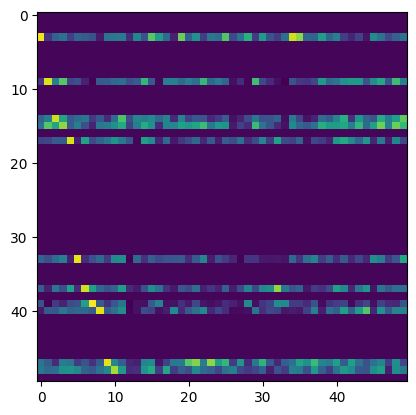

In [88]:
plt.imshow(mu0_pad)

In [56]:
sigma3 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
sigma3

0.27967561314541783

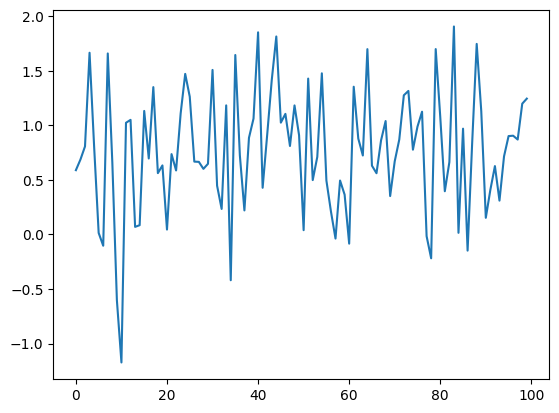

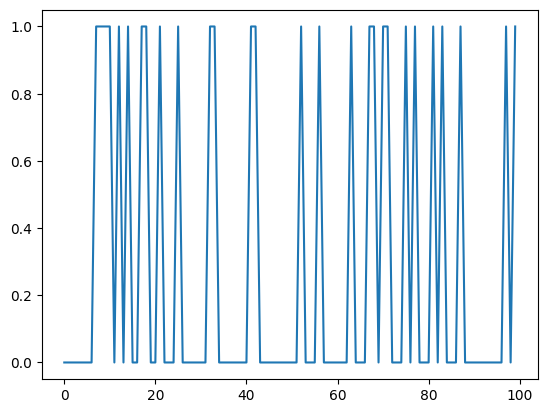

In [40]:
plt.plot(Y)
plt.show()

plt.plot(T)
plt.show()



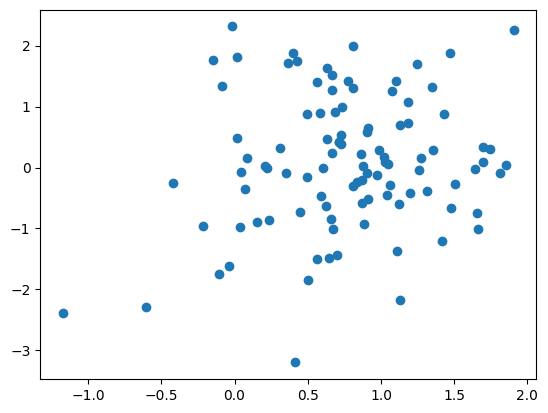

In [50]:
plt.scatter(Y, X[:, 4])